In [1]:
import sys
import numpy as np
import os
import json
import shutil

# Add the directory containing instruments.py to the Python path
custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
sys.path.append(custom_module_path)

import plotting_rewrite as plotting
import instruments_jax as inst

h5_original_file_path = "/home/rebeccaz/Github/vampires_calibration/mcmc/results/610nm_Adjusted_EM_Gain_with_IMR_offset_Angles_PM45_Shared_Priors_20000000_steps.h5"
h5_file_path = "/home/rebeccaz/Github/vampires_calibration/mcmc/results/610nm_Adjusted_EM_Gain_with_IMR_offset_Angles_PM45_Shared_Priors_20000000_steps_copy.h5"
shutil.copy2(h5_original_file_path, h5_file_path)
txt_file_path = "/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/610_with_IMR_offset_pm_1_degree_fixed_EM_gain_with_dichroic_best_fit_old_fit_values.txt"
txt_save_file_path = "/home/rebeccaz/Github/vampires_calibration/mcmc/results/610nm_Adjusted_EM_Gain_with_IMR_offset_Angles_PM45_Shared_Priors_20000000_steps.txt"

# Step 1: Defining System Dictionary

In [2]:
filter_wavelength = 610
wavelength_string = filter_wavelength
wavelength_index = 0
nsteps = 20000000
obs_mode = "MBI"

IPOL_em_gains = [1.14, 1.18, 1.18, 1.18]
MBI_em_gains = [1.23, 1.19, 1.2, 1.08]
if obs_mode == "IPOL":
    em_gain = IPOL_em_gains[wavelength_index]
elif obs_mode == "MBI":
    em_gain = MBI_em_gains[wavelength_index]

system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": 0, "epsilon": 0, "theta" : 0},
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": 0, "epsilon": 0, "theta": 0},
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": 0},
        },
    }
}

# Step 2: Loading Chains

In [3]:
chain, names = plotting.load_chain_and_labels(h5_file_path, txt_file_path, include_logf=True, copy_file=False)

# Check chain shape after loading
print("Chain shape (nsteps, nwalkers, ndim):", chain.shape)


Chain shape (nsteps, nwalkers, ndim): (567359, 28, 14)


## Step 2.5: Autocorrelation Time Diagnostics

In [4]:
import emcee

# Use the full loaded chain by default. Set a different range to estimate tau after burn-in.
autocorr_step_range = (0, None)
autocorr_thin = 1
autocorr_tol = 0  # Use 50 for emcee's usual convergence check; 0 always returns an estimate.

act_start, act_end = autocorr_step_range
if act_end is None:
    act_end = chain.shape[0]

if act_start < 0 or act_end > chain.shape[0] or act_start >= act_end:
    raise ValueError(f"Invalid autocorr_step_range {autocorr_step_range} for chain with {chain.shape[0]} steps.")

act_chain = chain[act_start:act_end:autocorr_thin, :, :]
if act_chain.shape[0] < 2:
    raise ValueError("Autocorrelation calculation needs at least two saved steps.")

autocorr_tau = emcee.autocorr.integrated_time(act_chain, tol=autocorr_tol, quiet=True)
autocorr_tau_steps = autocorr_tau * autocorr_thin
autocorr_nsteps = act_end - act_start
autocorr_neff = act_chain.shape[0] * act_chain.shape[1] / autocorr_tau
recommended_burn_in = int(2 * np.max(autocorr_tau_steps))
recommended_thinning = max(1, int(0.5 * np.min(autocorr_tau_steps)))

print(f"Autocorrelation step range: {act_start} to {act_end} (thin={autocorr_thin})")
print(f"{'parameter':<35} {'tau [steps]':>12} {'nsteps/tau':>12} {'N_eff':>12}")
for name, tau_steps, neff in zip(names, autocorr_tau_steps, autocorr_neff):
    print(f"{name:<35} {tau_steps:12.1f} {autocorr_nsteps / tau_steps:12.1f} {neff:12.0f}")

print(f"Mean tau: {np.mean(autocorr_tau_steps):.1f} steps")
print(f"Max tau: {np.max(autocorr_tau_steps):.1f} steps")
print(f"Recommended burn-in: {recommended_burn_in} steps")
print(f"Recommended thinning: {recommended_thinning} steps")


Autocorrelation step range: 0 to 567359 (thin=1)
parameter                            tau [steps]   nsteps/tau        N_eff
dichroic.phi                             25043.5         22.7          634
dichroic.epsilon                         29869.7         19.0          532
dichroic.theta                           36679.6         15.5          433
flc.phi                                  22225.7         25.5          715
flc.delta_theta                          31721.7         17.9          501
optics.phi                               25311.2         22.4          628
optics.epsilon                           20337.5         27.9          781
optics.theta                             24048.4         23.6          661
image_rotator.phi                        18013.5         31.5          882
image_rotator.delta_theta                 5954.5         95.3         2668
hwp.phi                                  24200.1         23.4          656
hwp.delta_theta                          19859.6   

# Step 2.6: Apply Recommended Burn-in and Thinning


Using burn-in = 73359 saved steps and thinning = 2977 saved steps.
Posterior chain shape (nthinned_steps, nwalkers, ndim): (166, 28, 14)
Original saved steps included: 73359 to 564564 (166 thinned samples per walker).
dichroic.phi (waves): 0.42089 ± 0.01880
dichroic.epsilon (): 0.52019 ± 0.23185
dichroic.theta (): 44.95993 ± 13.67264
flc.phi (waves): 0.60394 ± 0.01429
flc.delta_theta (): 19.43513 ± 10.35678
optics.phi (waves): 0.38017 ± 0.06190
optics.epsilon (): 0.00596 ± 0.01042
optics.theta (): -23.26118 ± 6.82936
image_rotator.phi (waves): 0.22018 ± 0.00206
image_rotator.delta_theta (): -0.18787 ± 1.05188
hwp.phi (waves): 0.44092 ± 0.00389
hwp.delta_theta (): 0.10767 ± 1.67057
lp.theta (): 0.81401 ± 1.65207
log_f (): -7.01442 ± 2.35841


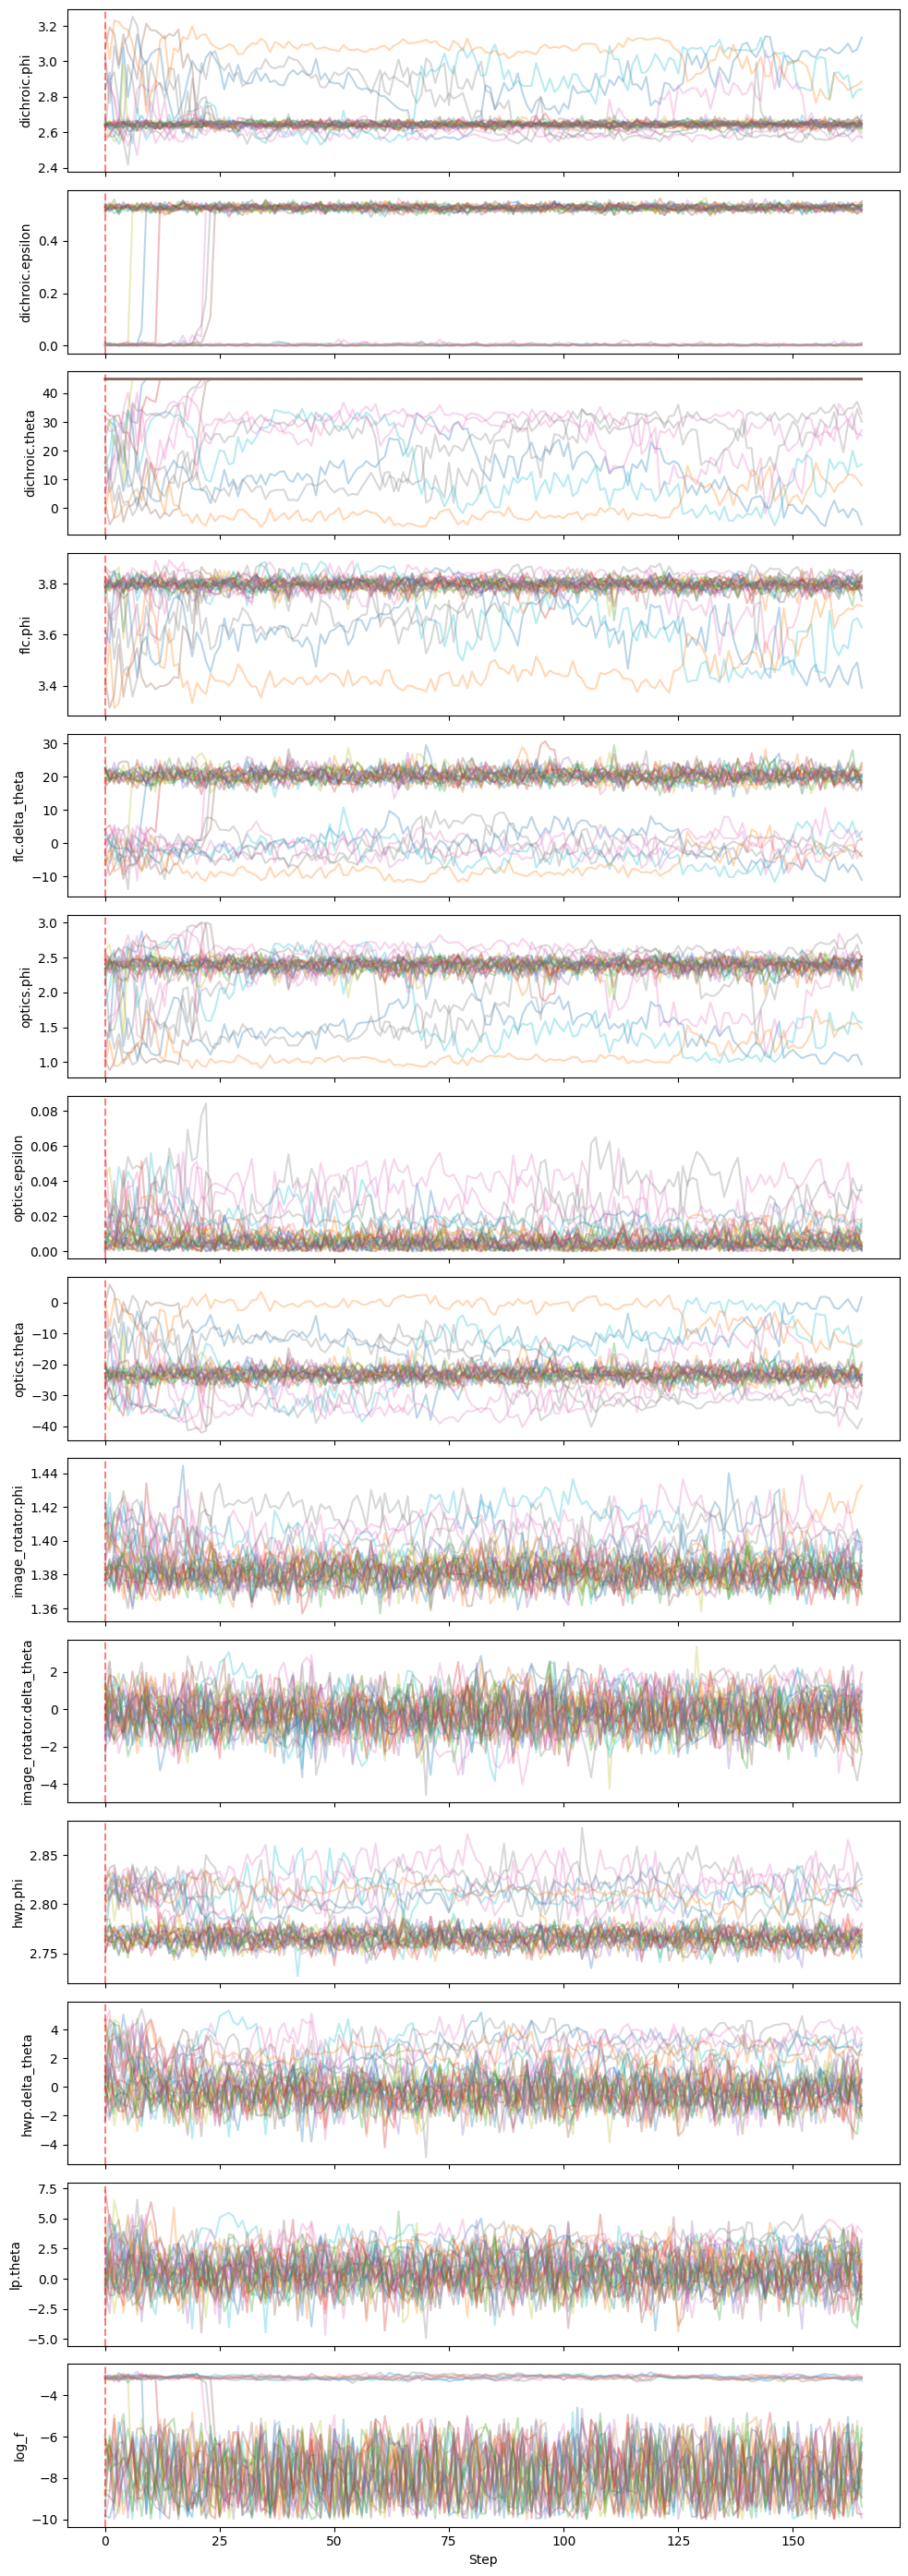

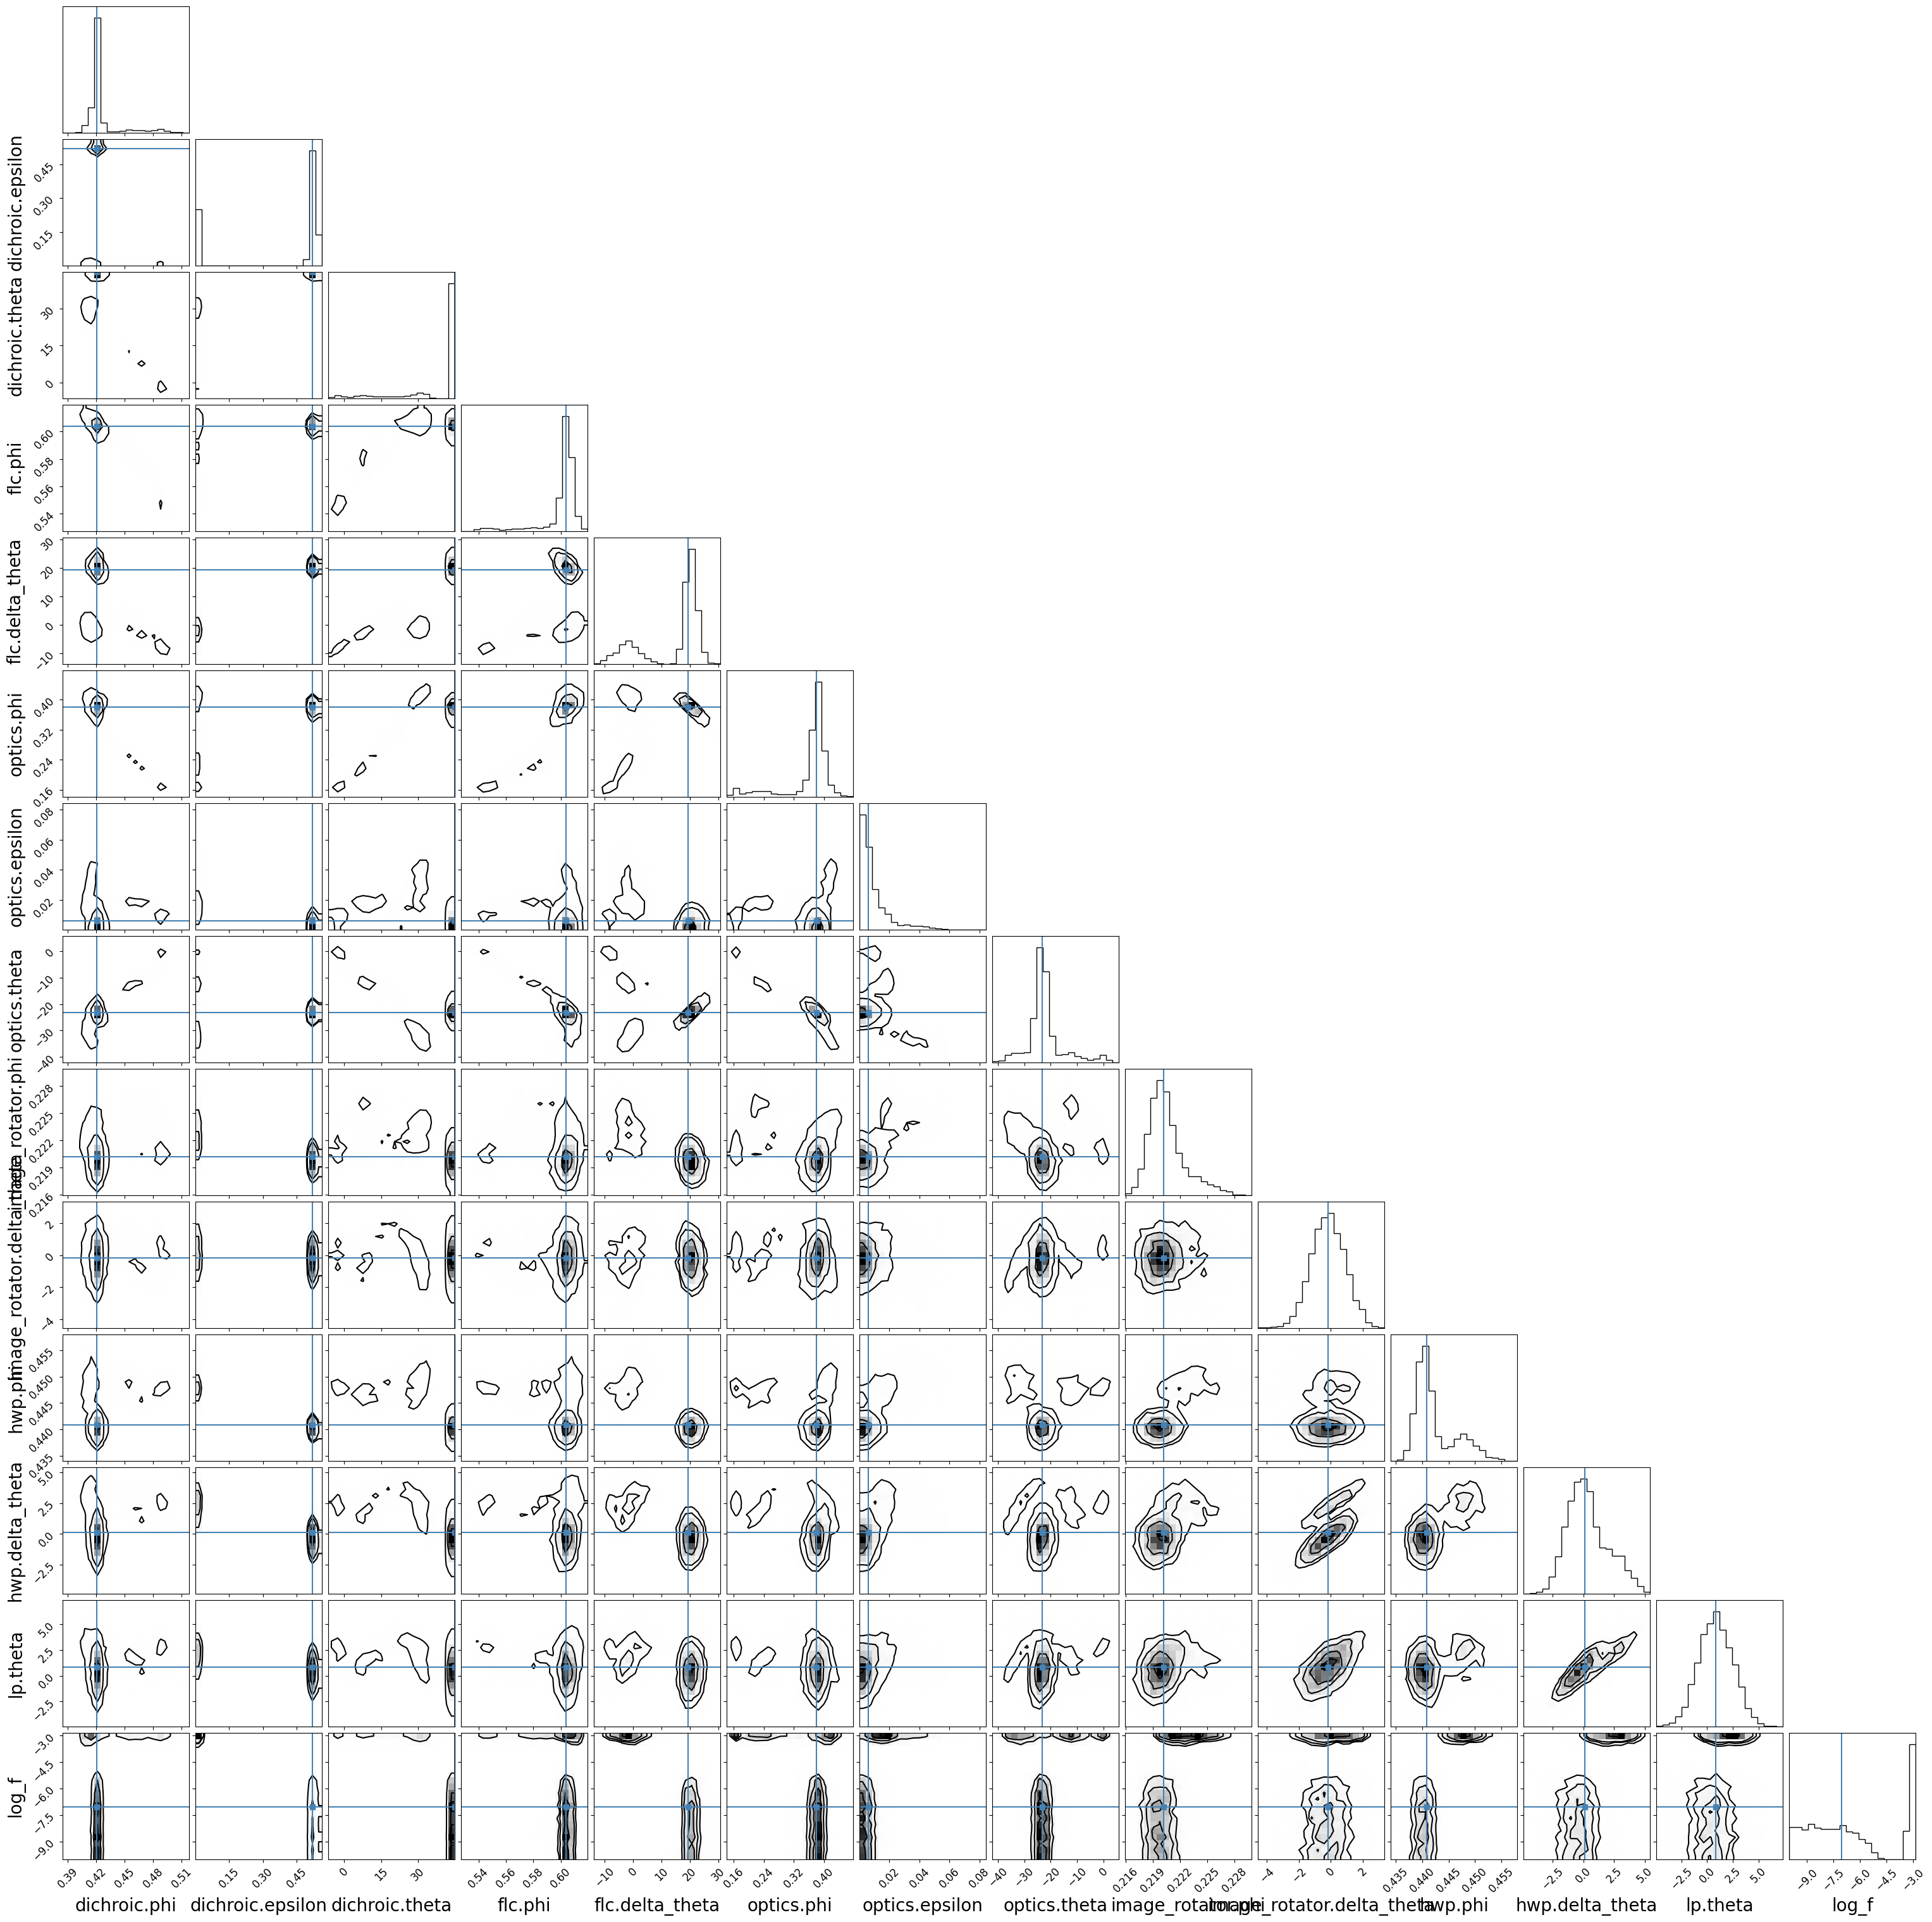

In [5]:
burn_in = recommended_burn_in
thinning = recommended_thinning

if burn_in < 0 or burn_in >= chain.shape[0]:
    raise ValueError(f"Invalid burn_in {burn_in} for chain with {chain.shape[0]} steps.")
if thinning < 1:
    raise ValueError(f"Invalid thinning {thinning}; thinning must be >= 1.")

posterior_chain = chain[burn_in::thinning, :, :]
posterior_step_numbers = np.arange(burn_in, chain.shape[0], thinning)
if posterior_chain.shape[0] < 1:
    raise ValueError("No posterior samples remain after applying burn-in and thinning.")

chain_step_range = (0, None)
corner_plot_step_range = (0, None)

print(f"Using burn-in = {burn_in} saved steps and thinning = {thinning} saved steps.")
print("Posterior chain shape (nthinned_steps, nwalkers, ndim):", posterior_chain.shape)
print(
    f"Original saved steps included: {posterior_step_numbers[0]} to "
    f"{posterior_step_numbers[-1]} ({posterior_chain.shape[0]} thinned samples per walker)."
)

# Print posterior summary for the thinned chain and save the median-fit text file.
plotting.summarize_posteriors(
    posterior_chain,
    names,
    system_dict,
    step_range=corner_plot_step_range,
    txt_save_file_path=txt_save_file_path,
    txt_file_path=txt_file_path,
)

# Plot trace plots after burn-in/thinning.
plotting.plot_trace(posterior_chain, names, step_range=chain_step_range, max_walkers=100)

# Plot corner plot from the flattened thinned posterior chain.
plotting.plot_corner_flat(posterior_chain, names, step_range=corner_plot_step_range)


# Step 3: Plot median configuration of posteriors

In [6]:
file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv"

interleaved_values, interleaved_stds, configuration_list = inst.read_csv(file_path, 
    obs_mode = obs_mode, obs_filter = wavelength_string)

In [7]:
# Loading in median parameters
with open(txt_save_file_path, "r") as f:
    past_fit = json.load(f)

# print(past_fit)

theta_pol = past_fit["lp"]["theta"]
delta_HWP = past_fit["hwp"]["phi"] 
offset_HWP = past_fit["hwp"]["delta_theta"]
delta_derot = past_fit["image_rotator"]["phi"] 
offset_derot = past_fit["image_rotator"].get("delta_theta", 0)
delta_opts = past_fit["optics"]["phi"]
epsilon_opts = past_fit["optics"]["epsilon"]
rot_opts = past_fit["optics"]["theta"]
delta_FLC = past_fit["flc"]["phi"] 
rot_FLC = past_fit["flc"]["delta_theta"]
delta_dichroic = past_fit["dichroic"]["phi"]
epsilon_dichroic = past_fit["dichroic"]["epsilon"]
rot_dichroic = past_fit["dichroic"]["theta"]

print(delta_HWP)

# NOTE: Components must be listed downstream to upstream
# Define the instrument configuration as a system dictionary

system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {
                "phi": delta_dichroic * 2 * np.pi,
                "epsilon": epsilon_dichroic,
                "theta": rot_dichroic,
            },
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {
                "phi": delta_FLC * 2 * np.pi,
                "theta": 0,  # not fitted
                "delta_theta": rot_FLC,
            },
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {
                "phi": delta_opts * 2 * np.pi,
                "epsilon": epsilon_opts,
                "theta": rot_opts,
            },
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {
                "phi": delta_derot * 2 * np.pi,
                "theta": 0,  # not fitted
                "delta_theta": offset_derot,
            },
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {
                "phi": delta_HWP * 2 * np.pi,
                "theta": 0,  # not fitted
                "delta_theta": offset_HWP,
            },
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": theta_pol},
        },
    }
}

system_mm = inst.generate_system_mueller_matrix(system_dict)
print(system_mm.evaluate())


0.44091670676818956
[[0.59330892 0.59306943 0.01685622 0.        ]
 [0.59330892 0.59306943 0.01685622 0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]]


logl value: 130.42078781542574


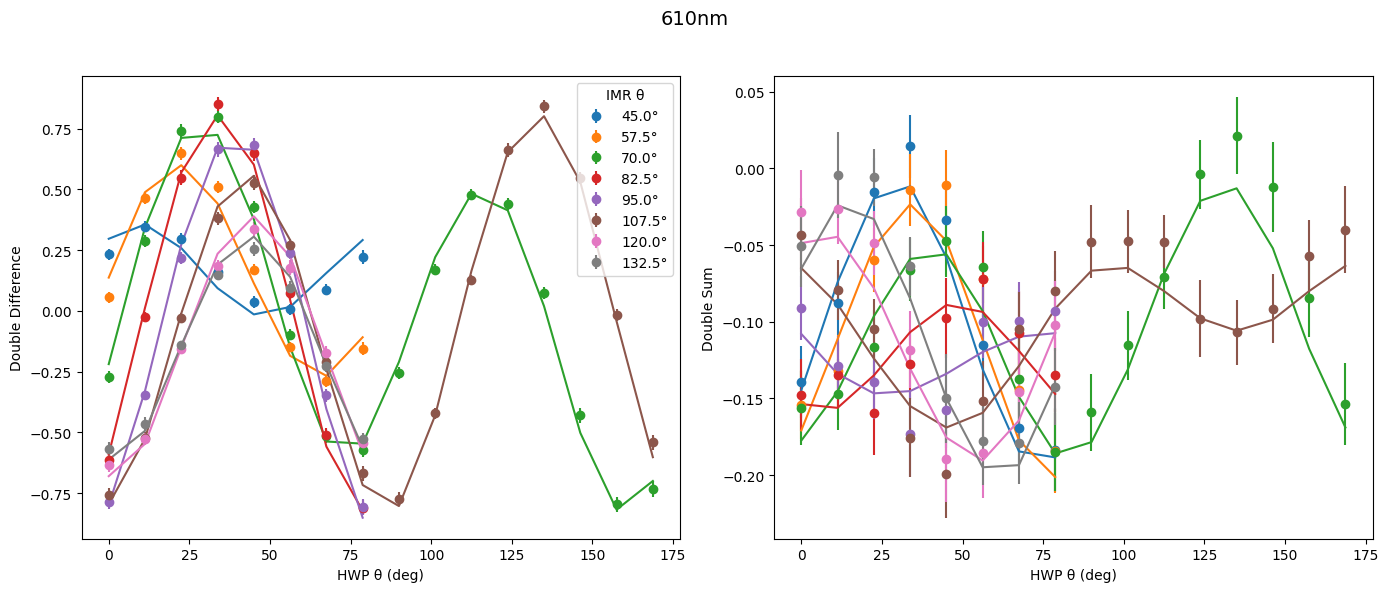

In [8]:
# Fittin for all parameters

p0 = {
    "wollaston": {"transmission_ratio": em_gain}, 
}

p0_values, p0_keywords = inst.parse_configuration(p0)
s_in = np.array([1, 0, 0, 0])
logl_value = inst.logl(p0_values, p0_keywords, system_mm, interleaved_values, interleaved_stds, configuration_list,
    s_in=s_in, logl_function=None, process_dataset=inst.process_dataset, process_errors=inst.process_errors, 
    process_model=inst.process_model)
print("logl value: " + str(logl_value))

# TODO: Add an initial plot block here
# Plotting intial plot
# updated_system_mm = inst.update_system_mm(p0_values, p0_keywords, system_mm)
model = inst.model(p0_values, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)

# Step 4: Plotting Random Chains for Fitting (UNDER CONSTRUCTION)

Plotting 100 random thinned posterior samples.
Thinned sample index range: 0 to 166.
Selected original (step, walker) pairs:
[(287703, 8), (534794, 12), (400829, 19), (299611, 19), (290680, 18), (451438, 23), (147784, 10), (231140, 19), (153738, 2), (418691, 25), (159692, 22), (314496, 23), (281749, 11), (472277, 12), (254956, 2), (409760, 13), (481208, 24), (168623, 22), (505024, 9), (546702, 10), (183508, 4), (522886, 23), (508001, 16), (132899, 24), (150761, 16), (478231, 27), (463346, 7), (165646, 7), (442507, 22), (141830, 5), (189462, 20), (341289, 21), (415714, 25), (326404, 20), (338312, 4), (213278, 22), (516932, 7), (454415, 3), (385944, 5), (451438, 4), (118014, 2), (487162, 14), (338312, 24), (263887, 6), (287703, 13), (305565, 15), (382967, 5), (106106, 3), (442507, 0), (183508, 13), (388921, 10), (513955, 25), (406783, 11), (251979, 10), (290680, 3), (299611, 11), (522886, 9), (320450, 18), (427622, 23), (436553, 8), (266864, 21), (251979, 14), (445484, 21), (109083, 16),

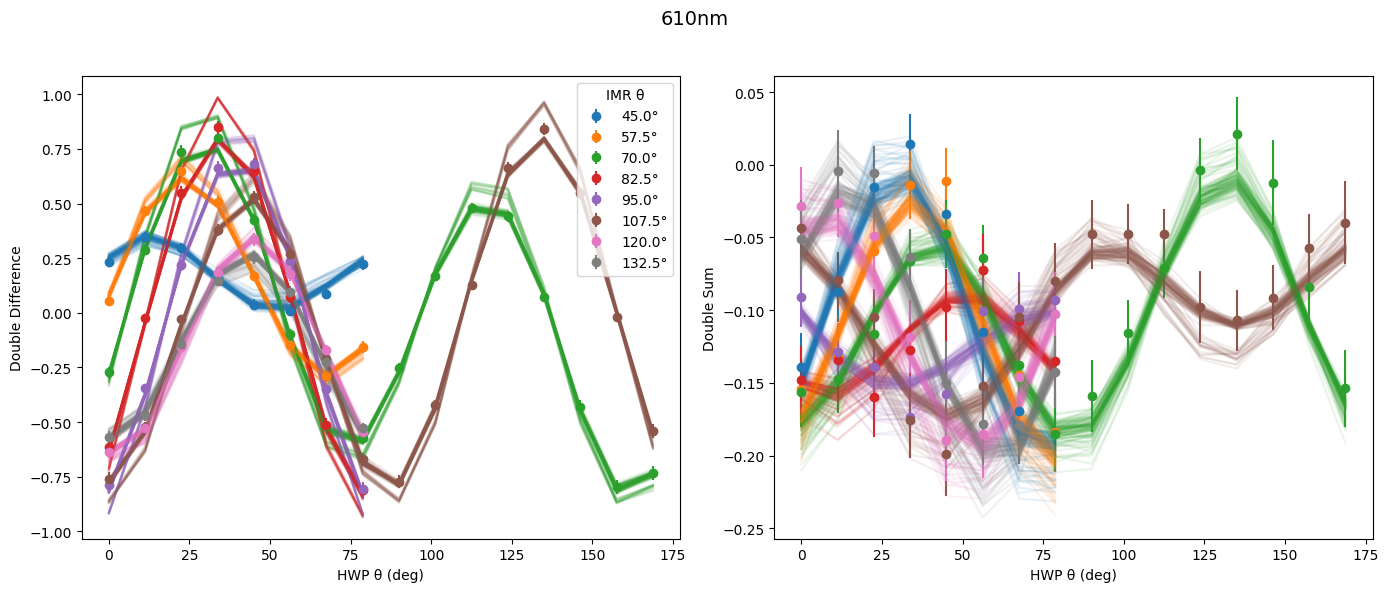

In [9]:
import importlib
inst = importlib.reload(inst)

# User settings
n_random_chains = 100
random_chain_step_range = corner_plot_step_range
random_chain_alpha = 0.1
random_seed = 42
imr_theta_filter = None

sampling_chain = globals().get("posterior_chain", chain)
sampling_step_numbers = globals().get("posterior_step_numbers", np.arange(sampling_chain.shape[0]))

with open(txt_file_path, "r") as f:
    fit_param_dict = json.load(f)
_, fit_param_keys = inst.parse_configuration(fit_param_dict)

start, end = random_chain_step_range
if end is None:
    end = sampling_chain.shape[0]

if start < 0 or end > sampling_chain.shape[0] or start >= end:
    raise ValueError(
        f"Invalid random_chain_step_range {random_chain_step_range} "
        f"for sampling chain with {sampling_chain.shape[0]} steps."
    )

chain_window = sampling_chain[start:end, :, :]
flat_chain_window = chain_window.reshape(-1, sampling_chain.shape[-1])
n_available_samples = flat_chain_window.shape[0]

if sampling_chain.shape[-1] < len(fit_param_keys):
    raise ValueError(
        f"Chain has {sampling_chain.shape[-1]} parameters, "
        f"but {len(fit_param_keys)} fitted parameters were found."
    )

if n_random_chains > n_available_samples:
    raise ValueError(f"Only {n_available_samples} samples available, but {n_random_chains} requested.")

rng = np.random.default_rng(random_seed)
selected_flat_indices = rng.choice(n_available_samples, size=n_random_chains, replace=False)
selected_sample_indices = start + (selected_flat_indices // sampling_chain.shape[1])
selected_steps = sampling_step_numbers[selected_sample_indices]
selected_walkers = selected_flat_indices % sampling_chain.shape[1]
random_chain_samples = flat_chain_window[selected_flat_indices, :len(fit_param_keys)]
random_chain_system_mm = inst.generate_system_mueller_matrix(system_dict)
s_in_random = globals().get("s_in", np.array([1, 0, 0, 0]))

random_chain_models = [
    inst.model(
        sample,
        fit_param_keys,
        random_chain_system_mm,
        configuration_list,
        s_in=s_in_random,
        process_model=inst.process_model,
    )
    for sample in random_chain_samples
]

print(f"Plotting {n_random_chains} random thinned posterior samples.")
print(f"Thinned sample index range: {start} to {end}.")
print("Selected original (step, walker) pairs:")
print(list(zip(selected_steps.tolist(), selected_walkers.tolist())))

inst.plot_data_and_model(
    interleaved_values,
    interleaved_stds,
    random_chain_models,
    configuration_list,
    wavelength=wavelength_string,
    imr_theta_filter=imr_theta_filter,
    model_alpha=random_chain_alpha,
    first_model_alpha=random_chain_alpha,
)


In [10]:
# import sys
# import os

# # Add the directory containing instruments.py to the Python path
# custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
# sys.path.append(custom_module_path)

# import plotting_rewrite as plotting
# import numpy as np

# all_step_range = (0, None)
# corner_plot_step_range = (24000, 25000)

# # Define the system configuration dictionary
# system_dict = {
#     "components": {
#         "wollaston": {
#             "type": "wollaston_prism_function",
#             "properties": {"beam": "o", "transmission_ratio": 1.18},
#         },
#         "dichroic": {
#             "type": "diattenuator_retarder_function",
#             "properties": {"phi": 0, "epsilon": 0, "theta": 0},
#         },
#         "flc": {
#             "type": "general_retarder_function",
#             "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
#         },
#         "optics": {
#             "type": "diattenuator_retarder_function",
#             "properties": {"phi": 0, "epsilon": 0, "theta": 0},
#         },
#         "image_rotator": {
#             "type": "general_retarder_function",
#             "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
#         },
#         "hwp": {
#             "type": "general_retarder_function",
#             "properties": {"phi": 0.5, "theta": 0, "delta_theta": 0},
#         },
#         "lp": {
#             "type": "general_linear_polarizer_function_with_theta",
#             "properties": {"theta": 0},
#         },
#     }
# }

# # Input paths and call plotting function
# h5_filename = "675nm_no_IMR_offset_with_dichroic.h5"
# txt_filename = "675-50nm.txt"
# csv_file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv"

# plotting.plot_mcmc_fits_double_diff_sum(
#     h5_filename=h5_filename,
#     txt_filename=txt_filename,
#     csv_path=csv_file_path,
#     filter_wavelength="675-50",
#     system_dict=system_dict,
#     wavelength_str="675nm",
#     n_samples=50,
#     step_range = all_step_range
# )
